# Homework 2

# Part 2: Numerical

Lotka-Volterra predator-prey model:

\begin{align}

&\frac{dx}{dt} = \alpha x - \beta xy, \\

&\frac{dy}{dt} = \delta xy - \gamma y,

\end{align}

where $x$ - population of hare (in thousands), $y$ - population of lunx (in thousands), and $\alpha, \beta, \gamma, \delta > 0$.

# 2.1 Synthetic Data 

# a) Generate data 

\begin{align}

&\alpha = 0.6, \beta = 0.025, \delta = 0.0125, \gamma = 0.5 \\

& x(0) = 30, y(0) = 4

\end{align}


System simulated for $t = 0,1,...,90$.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt 
import torch as tc
import torch.nn as nn

Running code on GPU (CUDA or MPS - for MacOS)

In [2]:
#Check for using GPU on MacOS (No CUDA for MacOS)
print(tc.backends.mps.is_available())
device = tc.device("mps" if tc.backends.mps.is_available() else "cpu")

#For using CUDA, e.g., on Symmetry, comment the above and run the below instead
#device = 'cuda' if tc.cuda.is_available() else 'cpu'

True


Solve the system of differenatial equations and plot the results

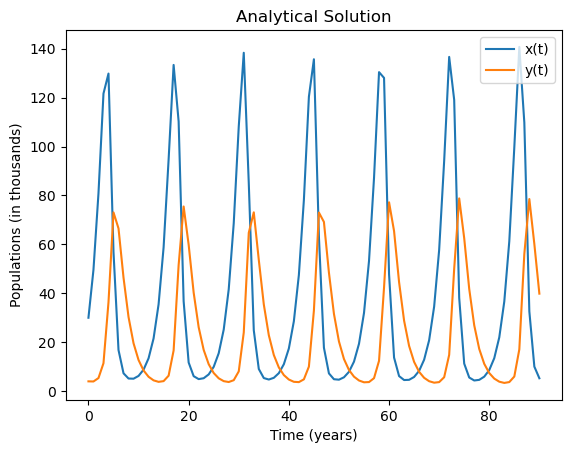

In [3]:
#Solving the system of differential equations

#Parameters
a = 0.6
b = 0.025
d = 0.0125
g = 0.5

#Initail conditions
x0 = 30
y0 = 4

#Time points to evaluate
t_eval = np.linspace(0, 90, 91)
t_span = (0,90)

#Define system of first order differential equations
def populations_ODEs(t, v):
    """
    t - time array 
    v = (x,y) - vector of x and y values
    """
    x, y = v

    dxdt = a*x - b*x*y
    dydt = d*x*y - g*y

    return np.array([dxdt, dydt], dtype=float)

#Solving
sol = solve_ivp(populations_ODEs, t_span, [x0, y0], t_eval=t_eval)

#Accessing the data for later use
t_tc=tc.from_numpy(sol.t).unsqueeze(1).float()
x_tc=tc.from_numpy(sol.y[0]).unsqueeze(1).float()
y_tc=tc.from_numpy(sol.y[1]).unsqueeze(1).float()

#Accesing the data for plot 
x_data = sol.y[0]
y_data = sol.y[1]


# Plot
fig, ax = plt.subplots()
ax.plot(t_eval, x_data, label="x(t)")
ax.plot(t_eval, y_data, label="y(t)")

ax.set_title("Analytical Solution")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Populations (in thousands)")
ax.legend()

fig.savefig("analytical_solution.png")
plt.show()


Below, solving for more data points for point d)

In [ ]:
#Time points to evaluate
t_eval_2 = np.linspace(0, 90, 300)

#Solving for more points
sol_2 = solve_ivp(populations_ODEs, t_span, [x0, y0], t_eval = t_eval_2)

# b) Approximate time derivatives using central differences

\begin{align}

&\dot{x}(t_i) \approx \frac{x_{i+1}-x_{i-1}}{2\Delta t}\\

&\dot{y}(t_i) \approx \frac{y_{i+1}-y_{i-1}}{2\Delta t}\\

\end{align}

In [5]:
#Approximating derivatives

dx_approx = np.zeros(len(t_eval))
dy_approx = np.zeros(len(t_eval))

for k in range(len(t_eval)):
    if k != 0 and k < (len(t_eval) -1):
        dx_approx[k] = (x_data[k+1] - x_data[k-1])/2
        dy_approx[k] = (y_data[k+1] - y_data[k-1])/2

#First value repeated 
dx_approx[0] = dx_approx[1]
dy_approx[0] = dy_approx[1]

#Last value repeated
dx_approx[-1] = dx_approx[-2]
dy_approx[-1] = dy_approx[-2]

#Check
#print(dx_approx)
#print(dy_approx)

# c) Estimating the parameters using linear regression

We define:

\begin{equation}

\omega^T = [\alpha, \beta, \gamma, \delta].

\end{equation}

The system becomes:

\begin{equation}

\frac{d}{dt} 
\begin{bmatrix} x \\ y \end{bmatrix}
=
\begin{bmatrix} x & -xy & 0 & 0 \\ 0 & 0 & -y & xy \end{bmatrix} \omega = A(x,y) \omega,


\end{equation}

where 

\begin{equation}

A(x,y) \equiv
\begin{bmatrix} x & -xy & 0 & 0 \\ 0 & 0 & -y & xy \end{bmatrix}.

\end{equation}

To build a regression system, we need to stack all of the points:

\begin{equation}

\begin{bmatrix}
x_2  &- x_2 y_2 & 0 & 0 \\
0 & 0 & -y_2 & x_2 y_2 \\
\vdots & & & \vdots \\
x_{N-1} & - x_{N-1} y_{N-1} & 0 & 0 \\
0 & 0 & -y_{N-1} & x_{N-1} y_{N-1} 
\end{bmatrix}


\begin{bmatrix}
\alpha \\ \beta \\ \gamma \\ \delta
\end{bmatrix}
=
\begin{bmatrix}
\dot{x}_2 \\ \dot{y}_2 \\ \vdots \\ \dot{x}_{N-1} \\ \dot{y}_{N-1}
\end{bmatrix}.

\end{equation}

This is $A(x,y)\omega = b$ and the solution is:


\begin{equation}
\omega^* = (A^\top A)^{-1} A^\top b.
\end{equation}

In [6]:
#Trunckating all data

dx_lin_reg = dx_approx[1:-1]
dy_lin_reg = dy_approx[1:-1]
x_lin_reg = x_data[1:-1]
y_lin_reg = y_data[1:-1]


#Defining b vector

b = np.zeros(2*(len(dx_lin_reg)))

#even and odd counts
k_even = 0 
k_odd = 0 

for k in range(len(b)):
    if k % 2 == 0:
        b[k] = dx_approx[k_even]
        k_even += 1
    if k % 2 != 0:
        b[k] = dy_approx[k_odd]
        k_odd += 1

b_transpose = b.reshape(-1,1)

#Check
#print(b_transpose)

In [7]:
#Defining matrix A

A = np.zeros((2*(len(dx_lin_reg)),4))

#even and odd counts
i_even = 0 
i_odd = 0 

for i in range(2*(len(dx_lin_reg))):
    if i % 2 == 0:
        A[i,0] = x_lin_reg[i_even]
        A[i,1] = -1*x_lin_reg[i_even]*y_lin_reg[i_even]
        i_even += 1
    if i % 2 != 0:
        A[i,2] = - y_lin_reg[i_odd]
        A[i,3] = x_lin_reg[i_odd]*y_lin_reg[i_odd]
        i_odd += 1

#Check
#print(A)

In [8]:
#Solving the linear regression equations to get the parameters

A_transpose = A.T
w_lin_reg = ( np.linalg.inv(A_transpose@A) @ A_transpose @ b_transpose )

print('The parameters found with linear regression are:')
print(f'a ={w_lin_reg[0]}')
print(f'b ={w_lin_reg[1]}')
print(f'g ={w_lin_reg[2]}')
print(f'd ={w_lin_reg[3]}')

The parameters found with linear regression are:
a =[0.45417067]
b =[0.01151109]
g =[0.05753484]
d =[0.00564007]


The parameters found with linear regression are quite off compared to the real ones, especially parameters b ($\beta$) and d ($\delta$), which differ by about 50% of their value.

### Plotting with real and estimated numbers for comparison

In [9]:
#Solving the differential equation with the coefficients found with linear regression

#Solving the system of differential equations

#Parameters
a_lr = w_lin_reg[0,0]
b_lr= w_lin_reg[1,0]
d_lr = w_lin_reg[3,0]
g_lr = w_lin_reg[2,0]

#Initail conditions
x0 = 30
y0 = 4

#Time points to evaluate
t_eval = np.linspace(0, 90, 91)
t_span = (0,90)

#Define system of first order differential equations
def populations_ODEs_lr(t, v):
    """
    t - time array 
    v = (x,y) - vector of x and y values
    """
    x, y = v

    dxdt = a_lr*x - b_lr*x*y
    dydt = d_lr*x*y - g_lr*y

    return [dxdt, dydt]

#Solving
sol_lr = solve_ivp(populations_ODEs_lr, t_span, [x0, y0], t_eval=t_eval)

#Accessing the data for later use
#t_tc=tc.from_numpy(sol_lr.t).unsqueeze(1).float()
#x_tc=tc.from_numpy(sol_lr.y[0]).unsqueeze(1).float()
#y_tc=tc.from_numpy(sol_lr.y[1]).unsqueeze(1).float()

#Accesing the data for plot 
x_data_lr = sol_lr.y[0]
y_data_lr = sol_lr.y[1]


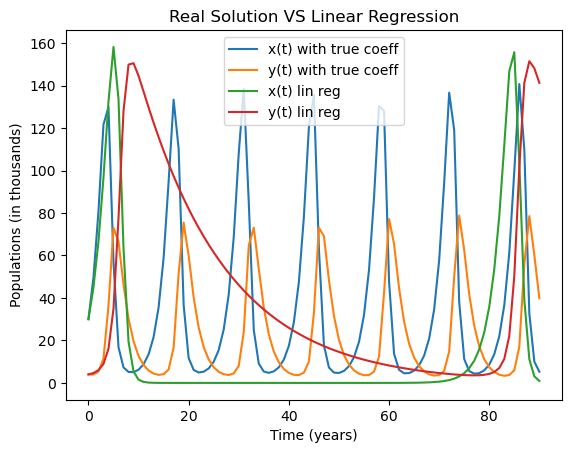

In [10]:
# Plot
fig, ax = plt.subplots()
ax.plot(t_eval, x_data, label="x(t) with true coeff")
ax.plot(t_eval, y_data, label="y(t) with true coeff")
ax.plot(t_eval, x_data_lr, label="x(t) lin reg")
ax.plot(t_eval, y_data_lr, label="y(t) lin reg")

ax.set_title("Real Solution VS Linear Regression")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Populations (in thousands)")
ax.legend()

fig.savefig("Linear_regression.png")
plt.show()

We find a large discrepancy for the simulation with the coefficients found with linear regression.

# d) Linear regression with more data points

COMMENT: Sometimes I needed to restart kernel to run solve_ivp for more points, because my jupyter notebook was probably storing the previous values.

In [11]:

#Accesing the data for plot from before (end of part a)
x_data_2 = sol_2.y[0]
y_data_2 = sol_2.y[1]


#Approximating more derivative points
dx_approx_2 = np.zeros(len(t_eval_2))
dy_approx_2 = np.zeros(len(t_eval_2))

for k in range(len(t_eval_2)):
    if k != 0 and k < (len(t_eval_2) -1):
        dx_approx_2[k] = (x_data_2[k+1] - x_data_2[k-1])/2
        dy_approx_2[k] = (y_data_2[k+1] - y_data_2[k-1])/2

#First value repeated 
dx_approx_2[0] = dx_approx_2[1]
dy_approx_2[0] = dy_approx_2[1]

#Last value repeated
dx_approx_2[-1] = dx_approx_2[-2]
dy_approx_2[-1] = dy_approx_2[-2]

#Trunckating all data
dx_lin_reg_2 = dx_approx_2[1:-1]
dy_lin_reg_2 = dy_approx_2[1:-1]
x_lin_reg_2 = x_data_2[1:-1]
y_lin_reg_2 = y_data_2[1:-1]


#Defining b vector
b_2 = np.zeros(2*(len(dx_lin_reg_2)))

#even and odd counts
k_even_2 = 0 
k_odd_2 = 0 

for k in range(len(b_2)):
    if k % 2 == 0:
        b_2[k] = dx_approx_2[k_even_2]
        k_even_2 += 1
    if k % 2 != 0:
        b_2[k] = dy_approx_2[k_odd_2]
        k_odd_2 += 1

b_transpose_2 = b_2.reshape(-1,1)

A_2 = np.zeros((2*(len(dx_lin_reg_2)),4))

#even and odd counts
i_even_2 = 0 
i_odd_2 = 0 

for i in range(2*(len(dx_lin_reg_2))):
    if i % 2 == 0:
        A_2[i,0] = x_lin_reg_2[i_even_2]
        A_2[i,1] = -1*x_lin_reg_2[i_even_2]*y_lin_reg_2[i_even_2]
        i_even_2 += 1
    if i % 2 != 0:
        A_2[i,2] = - y_lin_reg_2[i_odd_2]
        A_2[i,3] = x_lin_reg_2[i_odd_2]*y_lin_reg_2[i_odd_2]
        i_odd_2 += 1

A_transpose_2 = A_2.T
w_lin_reg_2 = ( np.linalg.inv(A_transpose_2@A_2) @ A_transpose_2 @ b_transpose_2 )

print('The parameters found with linear regression with more points are:')
print(f'a ={w_lin_reg_2[0]}')
print(f'b ={w_lin_reg_2[1]}')
print(f'g ={w_lin_reg_2[2]}')
print(f'd ={w_lin_reg_2[3]}')

The parameters found with linear regression with more points are:
a =[0.00594844]
b =[0.00024712]
g =[0.00490802]
d =[0.00012347]


In [12]:
#Solving the differential equation with the coefficients found with linear regression

#Solving the system of differential equations

#Parameters
a_lr_2 = w_lin_reg_2[0,0]
b_lr_2= w_lin_reg_2[1,0]
d_lr_2 = w_lin_reg_2[3,0]
g_lr_2 = w_lin_reg_2[2,0]

#Initail conditions
x0 = 30
y0 = 4


#Define system of first order differential equations
def populations_ODEs_lr_2(t, v):
    """
    t - time array 
    v = (x,y) - vector of x and y values
    """
    x, y = v

    dxdt = a_lr_2*x - b_lr_2*x*y
    dydt = d_lr_2*x*y - g_lr_2*y

    return [dxdt, dydt]

#Solving
sol_lr_2 = solve_ivp(populations_ODEs_lr_2, t_span, [x0, y0], t_eval=t_eval_2)

#Accessing the data for later use
#t_tc=tc.from_numpy(sol_lr.t).unsqueeze(1).float()
#x_tc=tc.from_numpy(sol_lr.y[0]).unsqueeze(1).float()
#y_tc=tc.from_numpy(sol_lr.y[1]).unsqueeze(1).float()

#Accesing the data for plot 
x_data_lr_2 = sol_lr_2.y[0]
y_data_lr_2 = sol_lr_2.y[1]

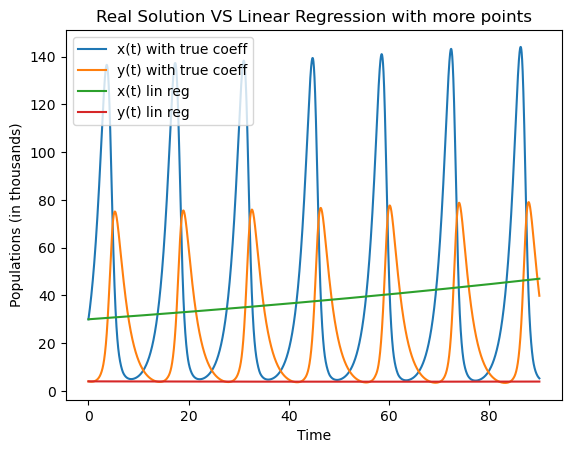

In [13]:
# Plot
fig, ax = plt.subplots()
ax.plot(t_eval_2, x_data_2, label="x(t) with true coeff")
ax.plot(t_eval_2, y_data_2, label="y(t) with true coeff")
ax.plot(t_eval_2, x_data_lr_2, label="x(t) lin reg")
ax.plot(t_eval_2, y_data_lr_2, label="y(t) lin reg")

ax.set_title("Real Solution VS Linear Regression with more points")
ax.set_xlabel("Time")
ax.set_ylabel("Populations (in thousands)")
ax.legend()

fig.savefig("Linear_regression_more_point.png")
plt.show()

Running the linear regression with more data points we get the coefficients $\alpha, \beta, \gamma, \delta$ that are way more off then before, but we get more periods on the graph. Linear regression gives great result for ... of point per year.